In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [2]:
df_scaled=pd.read_csv('restaurant_preprocessed.csv')
df_scaled.shape

(1696, 46)

# Application of PCA

In [3]:
pca= PCA()
pca.fit(df_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [4]:
explained_variance=pca.explained_variance_ratio_
explained_variance


array([2.12871179e-01, 2.08025965e-01, 1.38337260e-01, 7.41056044e-02,
       4.70114109e-02, 3.71733503e-02, 3.42024763e-02, 2.95583799e-02,
       2.80318732e-02, 2.56057551e-02, 2.44698420e-02, 2.37895351e-02,
       2.35256501e-02, 2.21172867e-02, 1.93797053e-02, 1.75508999e-02,
       9.52531572e-03, 5.79713120e-03, 4.78376020e-03, 4.10313038e-03,
       2.76834933e-03, 2.21130572e-03, 1.58548916e-03, 1.22061871e-03,
       8.13815127e-04, 4.30844161e-04, 3.69279562e-04, 2.01727851e-04,
       1.46914304e-04, 1.35901196e-04, 8.55471284e-05, 3.39485401e-05,
       1.24243524e-05, 7.49894808e-06, 6.68022997e-06, 4.10803800e-06,
       3.65940388e-08, 3.77298795e-11, 4.32325111e-12, 8.17260806e-17,
       3.14118365e-17, 2.70680128e-17, 1.09177411e-17, 7.33179956e-19,
       0.00000000e+00, 0.00000000e+00])

In [5]:
cumulative_variance=np.cumsum(pca.explained_variance_ratio_)
cumulative_variance


array([0.21287118, 0.42089714, 0.5592344 , 0.63334001, 0.68035142,
       0.71752477, 0.75172725, 0.78128563, 0.8093175 , 0.83492325,
       0.8593931 , 0.88318263, 0.90670828, 0.92882557, 0.94820527,
       0.96575617, 0.97528149, 0.98107862, 0.98586238, 0.98996551,
       0.99273386, 0.99494517, 0.99653066, 0.99775127, 0.99856509,
       0.99899593, 0.99936521, 0.99956694, 0.99971385, 0.99984976,
       0.9999353 , 0.99996925, 0.99998168, 0.99998918, 0.99999586,
       0.99999996, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        ])

# Scree Plot

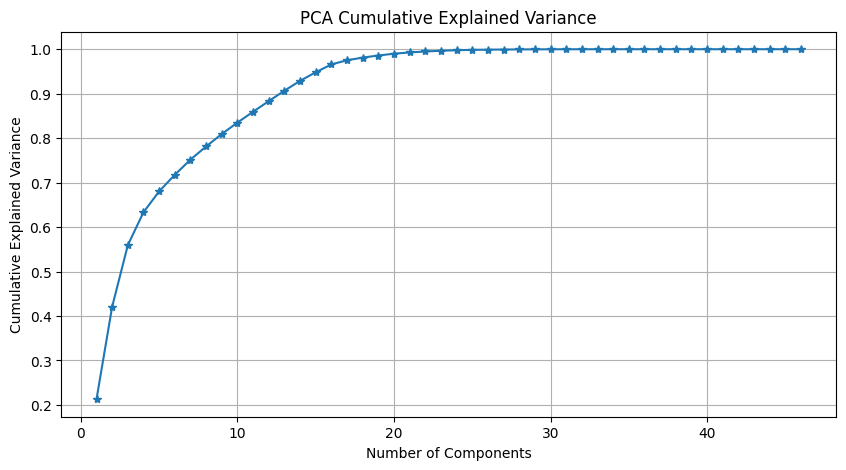

In [6]:
plt.figure(figsize=(10,5))
plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='*'
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True)
plt.show()

In [7]:
cumulative_variance[:20]

array([0.21287118, 0.42089714, 0.5592344 , 0.63334001, 0.68035142,
       0.71752477, 0.75172725, 0.78128563, 0.8093175 , 0.83492325,
       0.8593931 , 0.88318263, 0.90670828, 0.92882557, 0.94820527,
       0.96575617, 0.97528149, 0.98107862, 0.98586238, 0.98996551])

# Final PCA Dataset

In [8]:
pca=PCA(n_components=13)
pca_data = pca.fit_transform(df_scaled)
pca_data.shape

(1696, 13)

In [9]:
pca_df= pd.DataFrame(
    pca_data,
    columns=[f'PC{i}' for i in range(1,14)]
)
pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,-2.597001,1.011065,-2.971778,-0.333912,2.278507,-0.634730,0.166559,-0.195364,2.459781,0.558171,-0.931293,-0.209417,0.184778
1,0.891916,2.794006,-0.052144,2.179925,0.659105,1.824653,-0.926039,-1.323695,0.082562,-0.157719,0.037653,-0.019318,0.403983
2,2.845831,4.464044,0.463796,-0.172536,2.459937,-0.071902,-0.694016,1.976989,0.122222,-0.449539,0.262531,-0.264870,0.083121
3,-0.689932,0.426694,-1.256530,-3.110379,0.343531,-1.194756,-0.932087,-1.293304,-0.109125,0.348089,-0.182990,0.295814,-0.773562
4,0.128078,1.027017,-1.064668,-0.695324,0.346350,1.191423,0.177487,-1.179823,-1.509223,-0.909760,0.411218,0.251274,-0.245940


In [10]:
print(pca.explained_variance_ratio_.sum())

0.9067082815579587


# Elbow Method

In [11]:
wcss=[]
for k in range (1,11):
    kmeans=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)


# Plot Elbow Curve

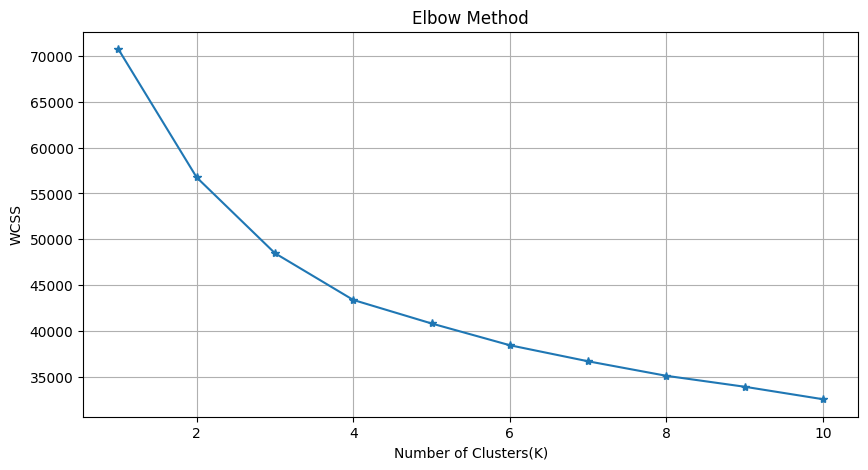

In [12]:
plt.figure(figsize=(10,5))
plt.plot(
    range(1,11),
    wcss,
    marker='*'
)
plt.xlabel('Number of Clusters(K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

# Silhouette Scores

In [13]:
from sklearn.metrics import silhouette_score
silhouette_scores=[]
for k in range (2,11):
    kmeans= KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels=kmeans.fit_predict(pca_data)
    score= silhouette_score(pca_data,labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.2209
K=3, Silhouette Score=0.1807
K=4, Silhouette Score=0.1828
K=5, Silhouette Score=0.1619
K=6, Silhouette Score=0.1566
K=7, Silhouette Score=0.1589
K=8, Silhouette Score=0.1455
K=9, Silhouette Score=0.1447
K=10, Silhouette Score=0.1486


# K-Means Clustering

In [14]:
kmeans=KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
clusters= kmeans.fit_predict(pca_data)
df_scaled['Cluster']=clusters
df_scaled['Cluster'].value_counts(normalize=True)*100

Cluster
1    33.962264
0    30.719340
2    22.405660
3    12.912736
Name: proportion, dtype: float64

In [15]:
df=pd.read_csv('restaurant_feature_engineered.csv')
df['Cluster']=clusters
df.to_csv('restaurant_clustered.csv',index=False)


# Cluster profiling and Business Interpretation

In [16]:
cluster_profile= df.groupby('Cluster')[
    ['GrowthFactor',
     'MonthlyOrders','AOV','TotalRevenue','TotalProfit','ProfitMargin','AggregatorDependence',
     'CostBurden','RevenueQuality','Expansion_Headroom']].mean().round(2)
cluster_profile


,GrowthFactor,MonthlyOrders,AOV,TotalRevenue,TotalProfit,ProfitMargin,AggregatorDependence,CostBurden,RevenueQuality,Expansion_Headroom
Cluster,,,,,,,,,,
0,1.03,1478.26,38.99,57565.93,9357.16,0.16,0.77,0.62,6.35,10.69
1,1.03,805.20,38.26,30718.12,4565.15,0.15,0.79,0.63,5.70,11.00
2,1.03,1312.42,38.23,50022.72,-3258.38,-0.07,0.78,0.88,-2.53,10.86
3,1.03,1307.97,38.55,50434.66,7305.41,0.15,0.55,0.70,5.77,10.92


In [17]:
df['Cluster'].value_counts()
(df['Cluster'].value_counts(normalize=True)*100).round(2)

Cluster
1    33.96
0    30.72
2    22.41
3    12.91
Name: proportion, dtype: float64

## Cluster Visualization

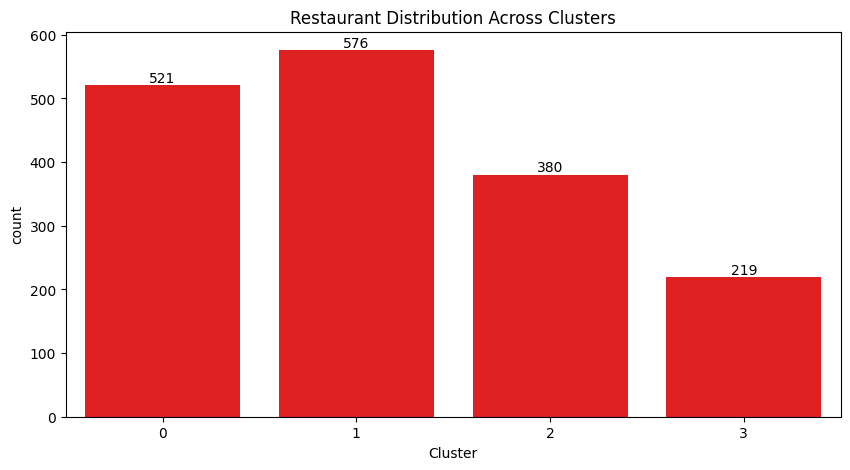

In [18]:
plt.figure(figsize=(10,5))
ax=sns.countplot(data=df,x='Cluster',color='red')
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.0f}',
        (p.get_x() +p.get_width()/2,p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Restaurant Distribution Across Clusters')
plt.show()

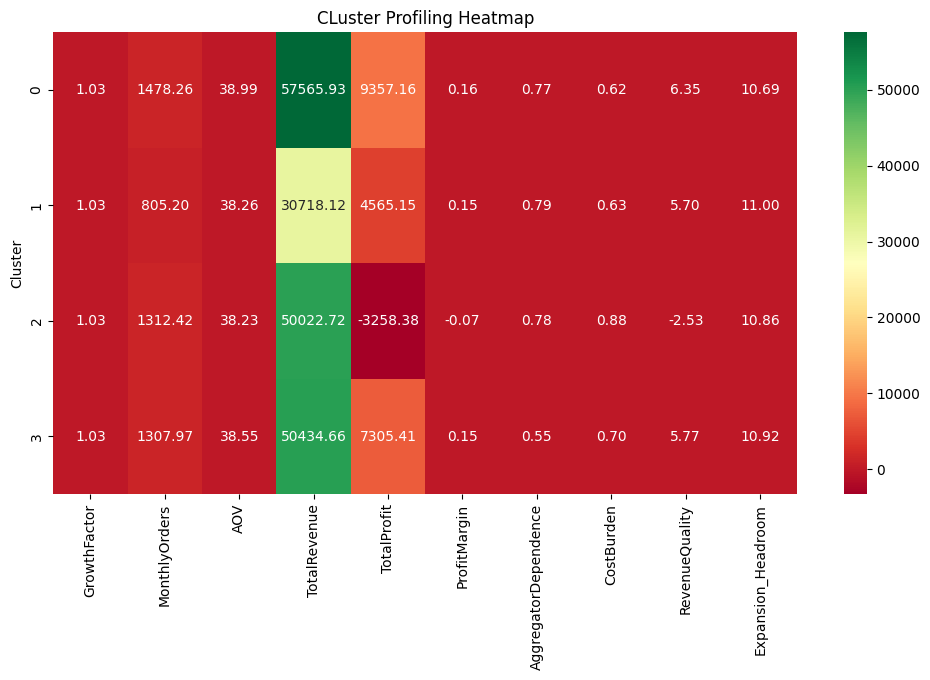

In [19]:
from sklearn.preprocessing import StandardScaler
cluster_profile_scaled=pd.DataFrame(
    StandardScaler().fit_transform(cluster_profile),
    columns=cluster_profile.columns,
    index=cluster_profile.index
)
plt.figure(figsize=(12,6))
sns.heatmap(cluster_profile,annot=True,fmt='.2f',cmap='RdYlGn')
plt.title('CLuster Profiling Heatmap')
plt.show()

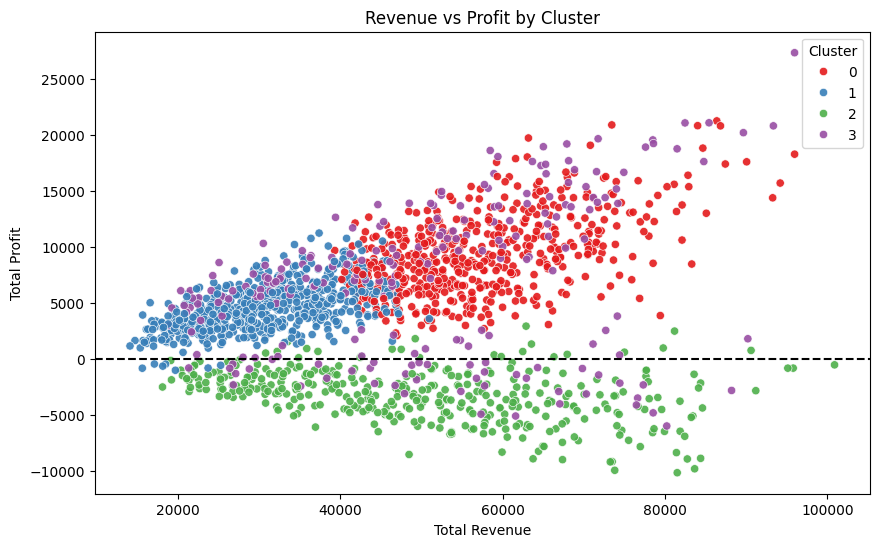

In [20]:

plt.figure(figsize=(10,6))
plt.axhline(y=0,color='black',linestyle='--')
sns.scatterplot(
    data=df,
    x='TotalRevenue',
    y='TotalProfit',
    hue='Cluster',
    palette='Set1',
    alpha=0.9
)
plt.title('Revenue vs Profit by Cluster')
plt.xlabel('Total Revenue')
plt.ylabel('Total Profit')
plt.show()

## Cluster Interpretation

In [21]:
pd.crosstab(df['Cluster'],df['CuisineType'])

CuisineType,Burgers,Chicken Dishes,Chinese,Indian,Japanese,Kebabs/Mediterranean,Pizza,Thai
Cluster,,,,,,,,
0,172,48,87,91,49,37,0,37
1,104,50,77,159,46,85,0,55
2,99,50,54,79,25,45,0,28
3,0,0,0,0,0,0,219,0


In [22]:
pd.crosstab(df['Cluster'],df['Segment'])

Segment,Cafe,Full-service,Ghost Kitchen,QSR
Cluster,,,,
0,221,0,81,219
1,222,7,93,254
2,0,380,0,0
3,61,65,23,70


In [23]:
pd.crosstab(df['Cluster'],df['Subregion'])

Subregion,CBD,North Shore,South Auckland,West Auckland
Cluster,,,,
0,113,115,136,157
1,149,131,145,151
2,99,90,94,97
3,49,47,66,57


# Growth Potential Index

In [24]:
gpi_features=[
    'GrowthFactor','ProfitMargin','RevenueQuality','Expansion_Headroom']


In [25]:
df[gpi_features].describe().round(2)

,GrowthFactor,ProfitMargin,RevenueQuality,Expansion_Headroom
count,1696.00,1696.00,1696.00,1696.00
mean,1.03,0.10,4.07,10.86
std,0.02,0.11,4.40,4.69
min,0.99,-0.18,-6.59,2.97
25%,1.03,0.01,0.40,6.30
50%,1.04,0.13,5.08,10.89
75%,1.05,0.19,7.20,14.70
max,1.05,0.34,15.61,18.90


In [26]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
gpi_scaled=scaler.fit_transform(df[gpi_features])
df['GPI']=gpi_scaled.mean(axis=1)
df['GPI'].describe().round(3)

count    1696.000
mean        0.000
std         0.613
min        -1.683
25%        -0.436
50%         0.064
75%         0.470
max         1.461
Name: GPI, dtype: float64

## Growth Potential Categories

In [27]:
df['GPI_Category']=pd.qcut(
    df['GPI'],q=3,labels=['Low Potential','Medium Potential','High Potential']
)
df['GPI_Category'].value_counts()

GPI_Category
Low Potential       566
Medium Potential    565
High Potential      565
Name: count, dtype: int64

### GPI Distribution

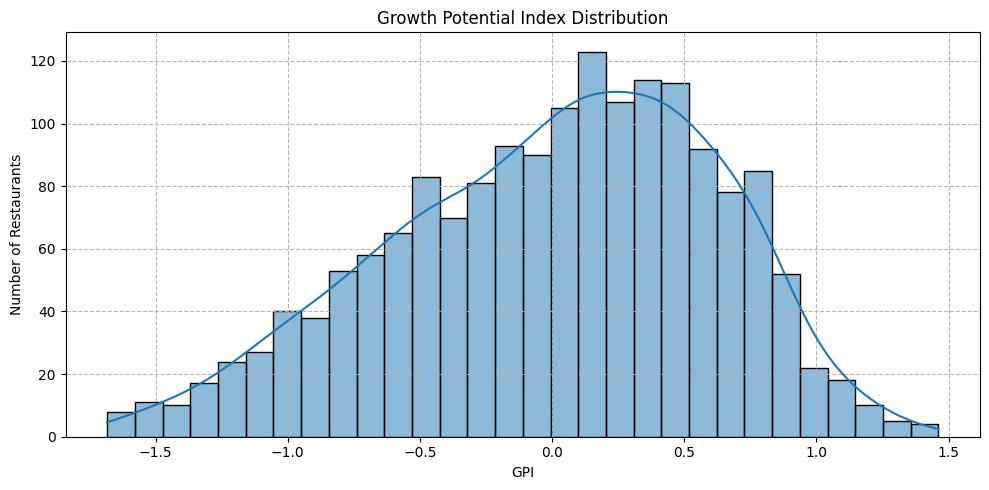

In [28]:
plt.figure(figsize=(10,5))
sns.histplot(data=df,x='GPI',bins=30,kde=True)
plt.title('Growth Potential Index Distribution')
plt.xlabel('GPI')
plt.ylabel('Number of Restaurants')
plt.grid(True,linestyle='--',alpha=0.9)
plt.tight_layout()
plt.show()

In [29]:
# average gpi by cluster......
df.groupby('Cluster')['GPI'].mean().sort_values(ascending=False).round(3)

Cluster
0    0.265
3    0.214
1    0.187
2   -0.770
Name: GPI, dtype: float64

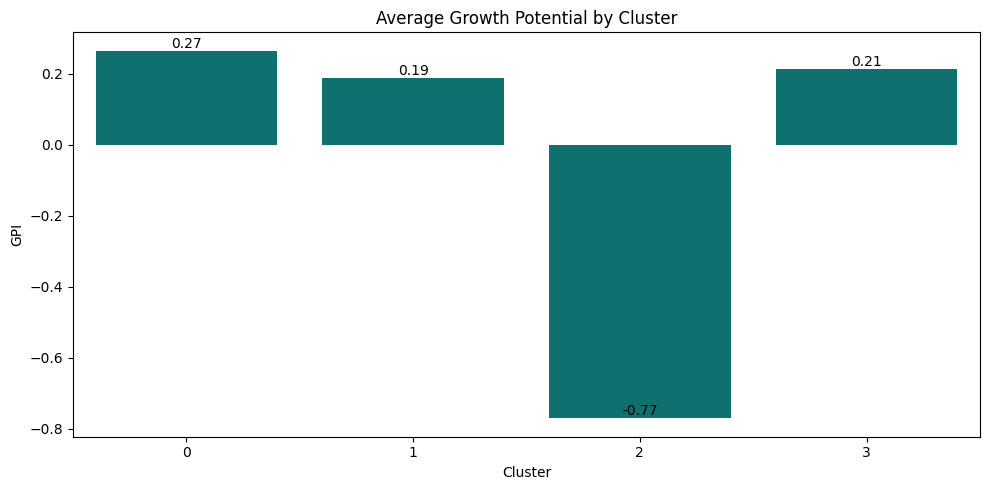

In [30]:
# cluster vs gpi bar chart......
cluster_gpi=df.groupby('Cluster')['GPI'].mean().reset_index()
plt.figure(figsize=(10,5))
ax=sns.barplot(data=cluster_gpi,x='Cluster',y='GPI',color='teal')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='bottom')
plt.title('Average Growth Potential by Cluster')
plt.tight_layout()
plt.show()

## Cluster Labeling

In [31]:
cluster_labels={0:'Growth Leaders',
                1:'Stable Local Performers',
                2:'Aggregator-dependent Low Margin',
                3:'Scalable Self-delivery Leaders'}
df['Cluster_Label']=df['Cluster'].map(cluster_labels)
df[['Cluster','Cluster_Label']].head()

,Cluster,Cluster_Label
0,1,Stable Local Performers
1,0,Growth Leaders
2,0,Growth Leaders
3,1,Stable Local Performers
4,0,Growth Leaders


## Cluster Composition Analysis(in percentage)

In [32]:
cuisine_pct= pd.crosstab(df['Cluster'],df['CuisineType'],normalize='index')*100
cuisine_pct.round(1)

CuisineType,Burgers,Chicken Dishes,Chinese,Indian,Japanese,Kebabs/Mediterranean,Pizza,Thai
Cluster,,,,,,,,
0,33.0,9.2,16.7,17.5,9.4,7.1,0.0,7.1
1,18.1,8.7,13.4,27.6,8.0,14.8,0.0,9.5
2,26.1,13.2,14.2,20.8,6.6,11.8,0.0,7.4
3,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0


In [33]:
segment_pct=pd.crosstab(df['Cluster'],df['Segment'],normalize='index')*100
segment_pct.round(1)

Segment,Cafe,Full-service,Ghost Kitchen,QSR
Cluster,,,,
0,42.4,0.0,15.5,42.0
1,38.5,1.2,16.1,44.1
2,0.0,100.0,0.0,0.0
3,27.9,29.7,10.5,32.0


In [34]:
subregion_pct=pd.crosstab(df['Cluster'],df['Subregion'],normalize='index')*100
subregion_pct.round(1)

Subregion,CBD,North Shore,South Auckland,West Auckland
Cluster,,,,
0,21.7,22.1,26.1,30.1
1,25.9,22.7,25.2,26.2
2,26.1,23.7,24.7,25.5
3,22.4,21.5,30.1,26.0


## Strategic Recommendations
cluster 0- Growth Leaders

In [35]:
#  Recommendation column creation......
recommendations={'Growth Leaders':'Expand',
                 'Stable Local Performers':'Hold/Stabilize',
                 'Aggregator-dependent Low Margin':'Optimize',
                 'Scalable Self-delivery Leaders':'Expand'}
df['Recommendation']=df['Cluster_Label'].map(recommendations)
df[['Cluster_Label','Recommendation']].head()

,Cluster_Label,Recommendation
0,Stable Local Performers,Hold/Stabilize
1,Growth Leaders,Expand
2,Growth Leaders,Expand
3,Stable Local Performers,Hold/Stabilize
4,Growth Leaders,Expand


In [36]:
important_cols=['Cluster','Cluster_Label','GPI','GPI_Category','Recommendation']
df[important_cols].head()

,Cluster,Cluster_Label,GPI,GPI_Category,Recommendation
0,1,Stable Local Performers,0.862843,High Potential,Hold/Stabilize
1,0,Growth Leaders,0.799903,High Potential,Expand
2,0,Growth Leaders,0.640372,High Potential,Expand
3,1,Stable Local Performers,-0.283580,Low Potential,Hold/Stabilize
4,0,Growth Leaders,0.306098,Medium Potential,Expand


In [37]:
df.to_csv('restaurant_final.csv',index=False)

In [38]:
df.to_excel('restaurant_final.xlsx',index=False)